# Creativity in vitro · Pre-processing with MNE

**Author:** Lina Lopes  **Date:** 2025-05-19  
This notebook converts a single OpenBCI  *raw* CSV recorded with an **OpenBCI Cyton + Daisy (14 active channels)** into 20 cleaned `RawArray` blocks, applies standard 10-20 montage, band-pass filtering (1–45 Hz + notch 50 Hz), performs quality-control metrics, and exports
per-block HTML reports.


**Pipeline outline**

1. Load raw CSV & unit conversion (counts → µV)
2. Confirm recording constants  
3. Assign montage & verify sensor layout (10-20)  
4. Filtering and remove GUI padding (crop 7 s + 3 s)  
5. Signal-noise-ratio and Quality Assurance
6. Reports
7. Next Steps

> **Key results**  
> * Median SNR improvement: **≈ +12 dB** after filtering & crop  
> * All 14 EEG channels within ±200 µV (peak)  
> * No blocks flagged for excessive variance


In [1]:
from pathlib import Path
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mne
import json

### Configuration dictionary

* `csv_path` Full path to the raw BrainFlow CSV.  
* `raw_dir` Directory for unfiltered `.fif` blocks (`blkNN_raw.fif`).  
* `fif_dir` Directory for filtered/cropped `.fif` blocks and QA reports.  
* `ch_order` Canonical 14-channel order used throughout the pipeline.

All hard-coded paths and parameters appear **exactly once** in `CONFIG`;
every subsequent cell references them, guaranteeing consistency.

In [2]:
CONFIG = {
    'csv_path': Path('../bids_dataset/sourcedata/openbci/ses-02/BrainFlow-RAW_2025-06-21_18-55-39_0.csv'),
    'raw_dir' : Path('../bids_dataset/sub-lina/ses-02/eeg'),
    'fif_dir' : Path('../bids_dataset/derivatives/filt_crop/sub-lina/ses-02/eeg/'),
    'qa_dir'  : Path('../bids_dataset/derivatives/qa_reports/sub-lina/ses-02/eeg/'),
    'ch_order': [
        'Fp1', 'Fp2', 'C3', 'C4', 'T3', 'T4',
        'O1',  'O2',  'F3', 'F4', 'Fz', 'Pz',
        'P3',  'P4'
    ]
}

## 1. Inspect raw file structure

The OpenBCI GUI writes **32 columns**:

| Column range | Content                                            |
|--------------|----------------------------------------------------|
| 0            | Sample index                                       |
| 1–16         | ADS1299 counts (EEG channels)                      |
| 17–19        | Accelerometer (X / Y / Z)                           |
| 20–22        | Analog inputs                                      |
| 23–31        | Miscellaneous (battery level, digital markers, timestamp, …) |

Only columns **1–16** are relevant for EEG; channels **N9P** and **N10P** are empty by design.

In [3]:
csv_path = CONFIG['csv_path']

df_raw=pd.read_csv(csv_path, header=None, sep="\t")
print("dataframe shape:", df_raw.shape)
df_raw.head()

dataframe shape: (440456, 32)


,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,0.0,-21142.716246,-20551.244384,-13654.211301,-33362.750216,-14469.312366,-13759.063334,-25295.178627,-48418.237080,-93750.011176,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.750525e+09,0.0
1,2.0,-42292.808568,-41117.911472,-27308.847285,-66735.938696,-28938.043587,-27502.815724,-50600.862575,-96842.531483,-187500.022352,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.750525e+09,0.0
2,4.0,-42289.120530,-41115.631594,-27305.203951,-66731.893031,-28928.477040,-27490.365802,-50599.521470,-96841.391545,-187500.022352,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.750525e+09,0.0
3,6.0,-42298.329449,-41120.884254,-27325.544038,-66737.570374,-28943.944448,-27510.415317,-50592.927705,-96843.738478,-187500.022352,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.750525e+09,0.0
4,8.0,-42322.312870,-41136.865751,-27352.030856,-66767.834636,-28957.377846,-27510.392965,-50638.480561,-96869.353577,-187500.022352,...,1.0,1.0,0.0,0.0,1.0,1.0,256.0,1.0,1.750525e+09,0.0


### Detecting Trigger Events from D12 (Button Press) with Debounce Logic

In this step, we detect the moments when a physical push button connected to the D12 digital input of the OpenBCI Cyton board was pressed.

- The D12 channel is recorded in column 22 of the raw CSV file.
- By default, the digital line is HIGH (`1`) and goes LOW (`0`) when the button is pressed.
- We detect transitions from `1 → 0` to identify the **exact moment** the button was activated.
- However, button presses can last multiple samples and sometimes cause brief digital fluctuations.
- To avoid false positives, we apply a **debounce filter** of 2.5 minutes (18750 samples), ensuring only one trigger is detected per recording block.

We then visualize the EEG signal with vertical red dashed lines marking each detected trigger. This helps confirm that the detected trigger points align with the expected start of each recording block.


In [4]:
# Initial settings
sfreq = 125  # Hz
col_d12 = 22  # D12 confirmed in column 22
min_spacing = int(sfreq * 60 * 2.5)  # 2.5 minutes = 18,750 samples

# D12 series: 1 = HIGH (released), 0 = LOW (pressed)
d12_series = df_raw.iloc[:, col_d12].fillna(1).astype(int)

# Detect 1 → 0 transitions (button pressed)
trigger_events = (d12_series.shift(1) == 1) & (d12_series == 0)
trigger_indices = df_raw[trigger_events].index.tolist()
print(f"Total transitions detected (1 → 0): {len(trigger_indices)}")

# Apply debounce: only consider new event if 2.5 minutes passed since last one
filtered_indices_final = []
last_idx = -min_spacing

for idx in trigger_indices:
    if idx - last_idx >= min_spacing:
        filtered_indices_final.append(idx)
        last_idx = idx

print(f"Real events after 2.5 minutes debounce: {len(filtered_indices_final)}")
print("Detected trigger indices:")
print(filtered_indices_final)


Total transitions detected (1 → 0): 28
Real events after 2.5 minutes debounce: 21
Detected trigger indices:
[3194, 23796, 45405, 66242, 87388, 107067, 127894, 149076, 170968, 190513, 210770, 232693, 253815, 275110, 296230, 316516, 337346, 358417, 379450, 400296, 422709]


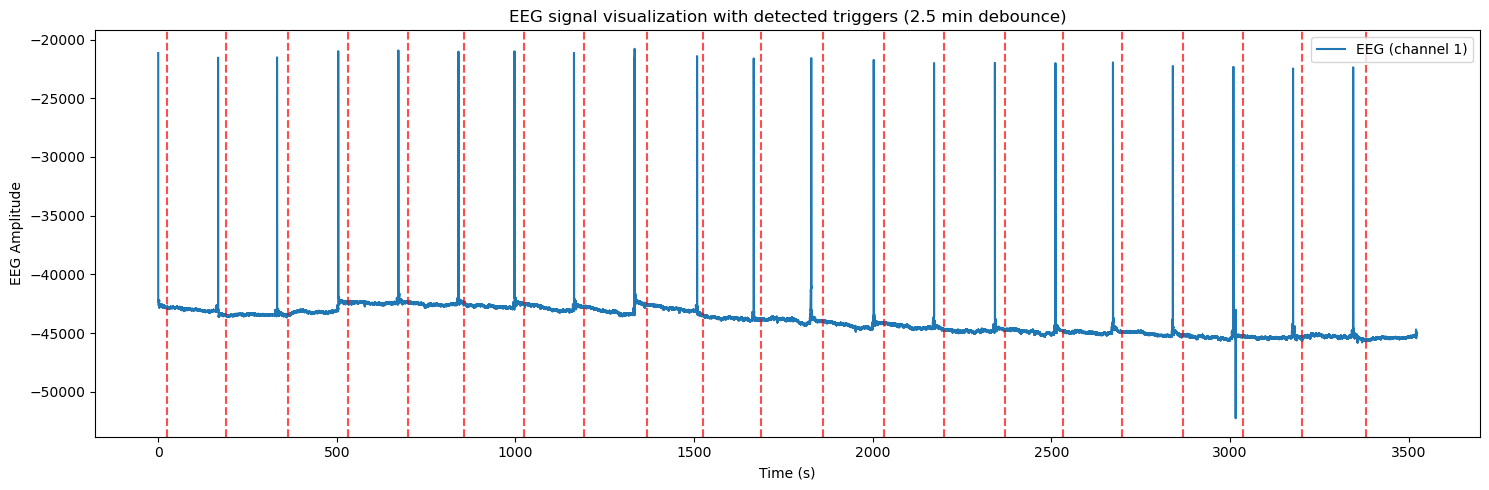

In [5]:
# Choose EEG channel for visualization
eeg_channel_col = 1  # can adjust to another channel if preferred
eeg_signal = df_raw.iloc[:, eeg_channel_col].astype(float)

# Relative time in seconds
sfreq = 125
time_sec = df_raw.index / sfreq

# Convert final trigger indices to time (seconds)
trigger_times_sec = [idx / sfreq for idx in filtered_indices_final]

# Plot
plt.figure(figsize=(15, 5))
plt.plot(time_sec, eeg_signal, label=f'EEG (channel {eeg_channel_col})')

# Red vertical lines at triggers
for t in trigger_times_sec:
    plt.axvline(t, color='red', linestyle='--', alpha=0.7)

plt.title("EEG signal visualization with detected triggers (2.5 min debounce)")
plt.xlabel("Time (s)")
plt.ylabel("EEG Amplitude")
plt.legend()
plt.tight_layout()
plt.show()


### Cleaning Raw Data: Dropping Unused Columns and Preserving D12

In this step, we remove unnecessary columns from the raw EEG dataset exported by the OpenBCI GUI.

- The original CSV contains extra columns such as auxiliary channels, digital channels, timestamps, and markers.
- We drop irrelevant columns (e.g., unused auxiliary or digital lines) while **preserving column 22**, which contains the digital input from **D12** — used to detect button presses marking the start of each recording block.
- After dropping, we rename the remaining columns using standard EEG channel labels along with `D12`, `timestamp`, and `marker`.
- We also compute a new column `time_sec` to represent the relative time from the beginning of the recording, which is useful for aligning events.

This cleaned version of the data is used for trigger detection, visualization, and conversion to BIDS format.


In [6]:
cols_to_drop = list(range(9, 11)) + [i for i in range(17, 30) if i != 22]
df_raw = df_raw.drop(df_raw.columns[cols_to_drop], axis=1)

eeg_labels = CONFIG["ch_order"]
col_names = ["sample_index"] + eeg_labels + ["D12", "timestamp", "marker"]
df_raw.columns = col_names

df_raw["time_sec"] = df_raw["timestamp"] - df_raw["timestamp"].iloc[0]

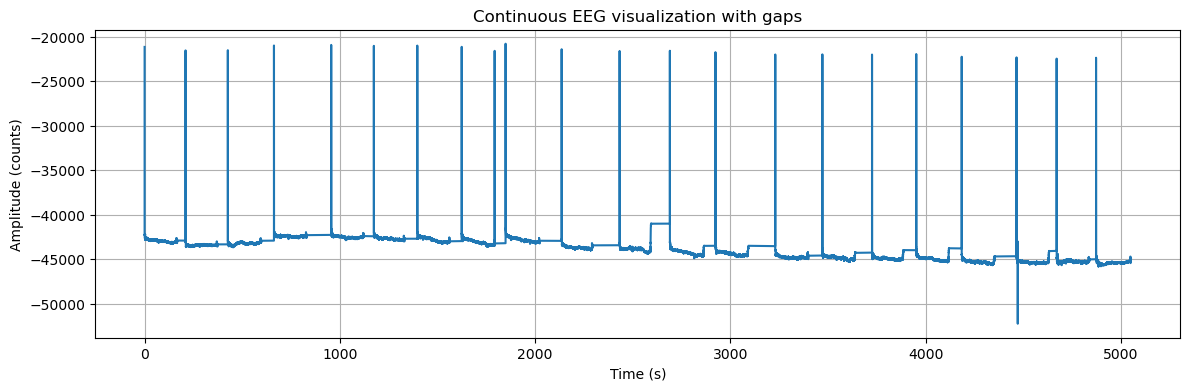

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14, 4))
plt.plot(df_raw["time_sec"], df_raw.iloc[:, 1])  # channel 0 (Fp1)
plt.title("Continuous EEG visualization with gaps")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (counts)")
plt.grid(True)
plt.show()

In [8]:
df_raw["timestamp_diff"] = df_raw["timestamp"].diff()
gap_threshold = 1.0  # seconds
gap_indices = df_raw.index[df_raw["timestamp_diff"] > gap_threshold].tolist()
print(gap_indices)

[20939, 41573, 62977, 84021, 105046, 124650, 145473, 166693, 188535, 208359, 228486, 250345, 271452, 292749, 313926, 334059, 355017, 376193, 397062, 418101]


In [9]:
def split_by_timestamp_gap(df, timestamp_col="timestamp", max_gap=1.0):
    df = df.copy()
    df["timestamp_diff"] = df[timestamp_col].diff()
    split_indices = df.index[df["timestamp_diff"] > max_gap].tolist()

    blocks = []
    start = 0
    for idx in split_indices:
        blocks.append(df.iloc[start:idx].reset_index(drop=True))
        start = idx
    blocks.append(df.iloc[start:].reset_index(drop=True))

    return blocks

In [10]:
blocks = split_by_timestamp_gap(df_raw, max_gap=1.0)

print(f"Number of detected blocks: {len(blocks)}")
for i, b in enumerate(blocks):
    duration = b["timestamp"].iloc[-1] - b["timestamp"].iloc[0]
    print(f"Block {i+1}: {len(b)} samples | {duration:.2f} s")


Number of detected blocks: 21
Block 1: 20939 samples | 167.43 s
Block 2: 20634 samples | 165.07 s
Block 3: 21404 samples | 171.24 s
Block 4: 21044 samples | 168.39 s
Block 5: 21025 samples | 168.21 s
Block 6: 19604 samples | 156.84 s
Block 7: 20823 samples | 166.55 s
Block 8: 21220 samples | 169.94 s
Block 9: 21842 samples | 174.77 s
Block 10: 19824 samples | 158.59 s
Block 11: 20127 samples | 161.03 s
Block 12: 21859 samples | 174.89 s
Block 13: 21107 samples | 168.87 s
Block 14: 21297 samples | 170.41 s
Block 15: 21177 samples | 169.42 s
Block 16: 20133 samples | 161.06 s
Block 17: 20958 samples | 167.67 s
Block 18: 21176 samples | 169.46 s
Block 19: 20869 samples | 167.00 s
Block 20: 21039 samples | 168.32 s
Block 21: 22355 samples | 178.87 s


In [11]:
blocks[0].head()

,sample_index,Fp1,Fp2,C3,C4,T3,T4,O1,O2,F3,F4,Fz,Pz,P3,P4,D12,timestamp,marker,time_sec,timestamp_diff
0,0.0,-21142.716246,-20551.244384,-13654.211301,-33362.750216,-14469.312366,-13759.063334,-25295.178627,-48418.237080,-21211.112584,-20743.827014,-38049.776918,-22494.639158,-41733.657328,-14418.283334,1.0,1.750525e+09,0.0,0.000000,NaN
1,2.0,-42292.808568,-41117.911472,-27308.847285,-66735.938696,-28938.043587,-27502.815724,-50600.862575,-96842.531483,-42826.702336,-42050.269789,-76717.691328,-45418.677678,-83901.094961,-29120.389118,1.0,1.750525e+09,0.0,0.005995,0.005995
2,4.0,-42289.120530,-41115.631594,-27305.203951,-66731.893031,-28928.477040,-27490.365802,-50599.521470,-96841.391545,-42843.488496,-42066.698321,-76724.061575,-45450.595969,-83894.389438,-29145.735996,1.0,1.750525e+09,0.0,0.013074,0.007079
3,6.0,-42298.329449,-41120.884254,-27325.544038,-66737.570374,-28943.944448,-27510.415317,-50592.927705,-96843.738478,-42824.623623,-42044.212466,-76714.852657,-45416.151931,-83902.883101,-29117.796316,1.0,1.750525e+09,0.0,0.019071,0.005997
4,8.0,-42322.312870,-41136.865751,-27352.030856,-66767.834636,-28957.377846,-27510.392965,-50638.480561,-96869.353577,-42865.527316,-42081.182251,-76745.251029,-45461.414213,-83924.027851,-29157.671828,1.0,1.750525e+09,0.0,0.026105,0.007034


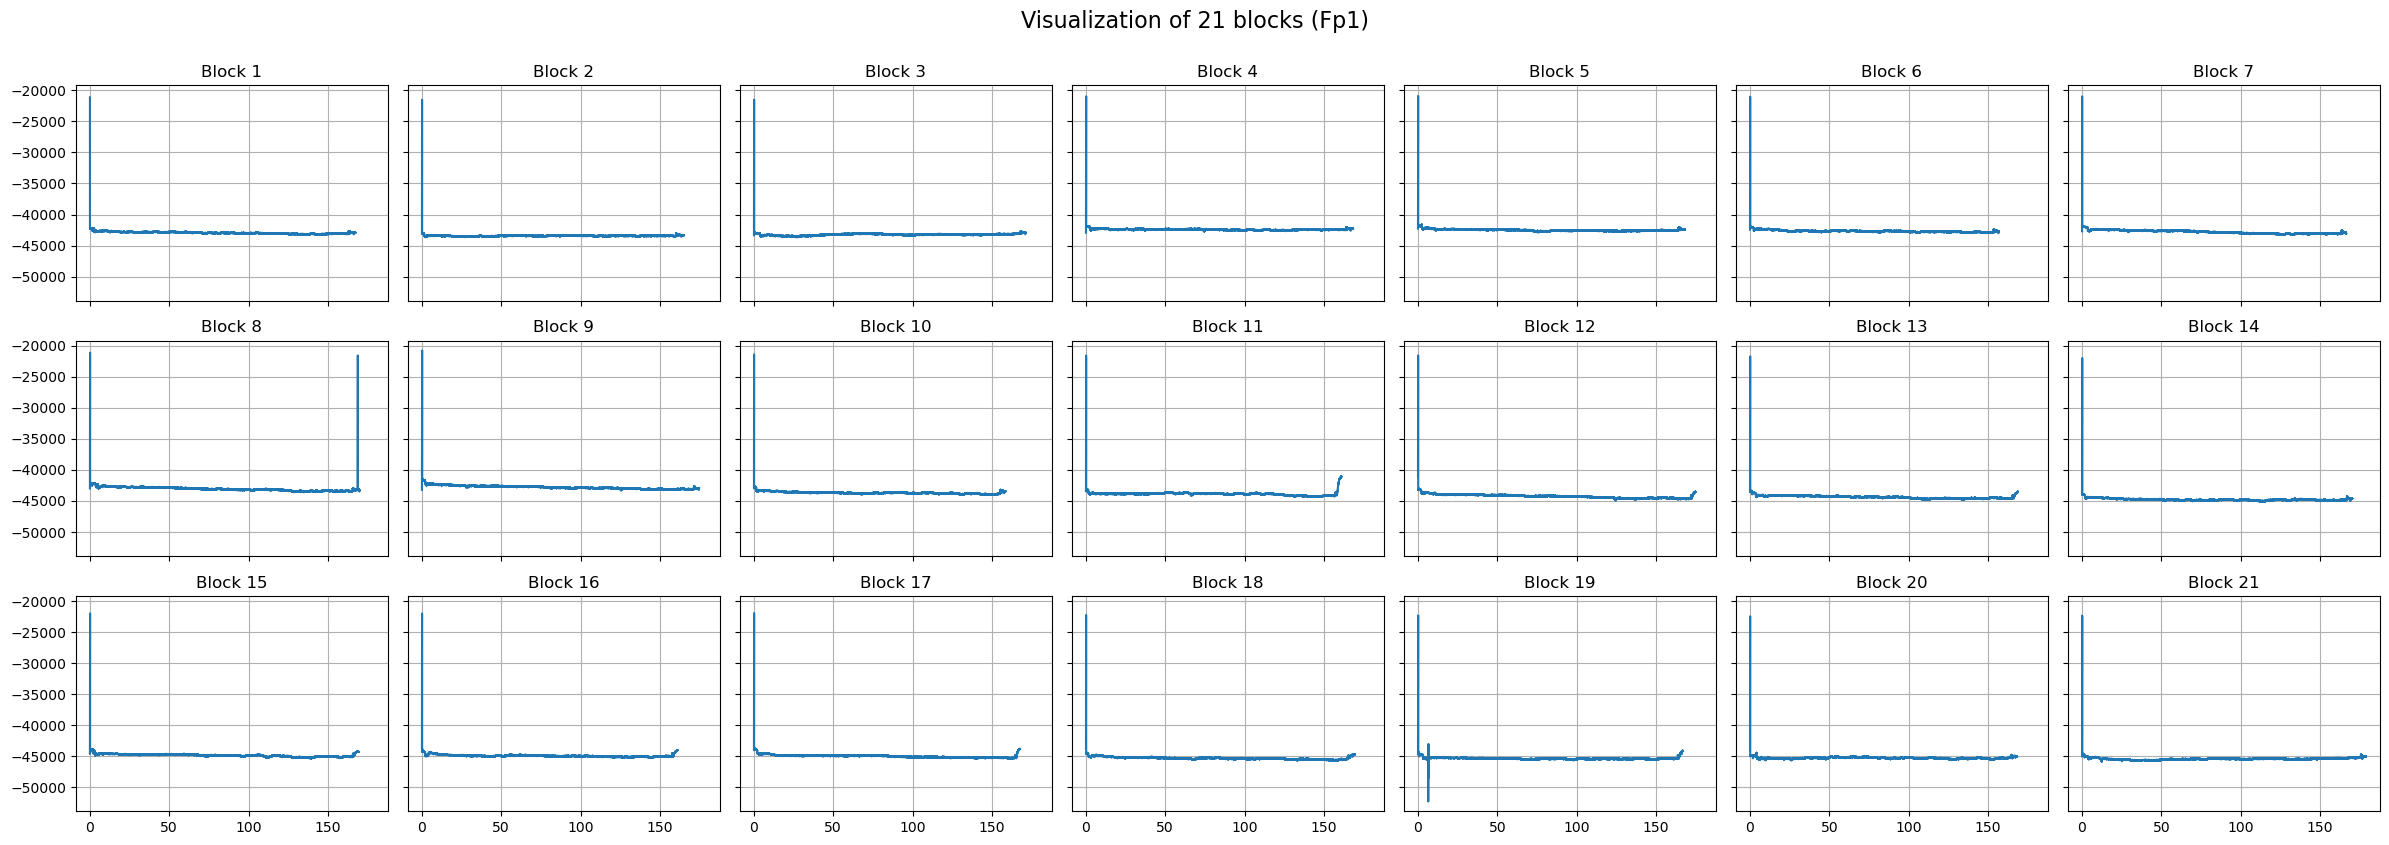

In [12]:
# Layout with 3 rows × 7 columns = 21 plots
fig, axs = plt.subplots(3, 7, figsize=(24, 8), sharex=True, sharey=True)
axs = axs.flatten()

for i, df_block in enumerate(blocks):
    df_block["time_sec"] = df_block["timestamp"] - df_block["timestamp"].iloc[0]
    axs[i].plot(df_block["time_sec"], df_block["Fp1"])
    axs[i].set_title(f"Block {i+1}")
    axs[i].grid(True)

# Remove extra plots if blocks < 21 (just for safety)
for j in range(len(blocks), len(axs)):
    axs[j].axis("off")

plt.tight_layout()
plt.suptitle("Visualization of 21 blocks (Fp1)", fontsize=16, y=1.05)
plt.show()


## 2. Confirm recording constants  

Before we build the 20 `.fif` files we need to verify two facts that every
sub-block will inherit:

1. **Effective sampling rate**  
   With the Daisy board attached the radio alternates two packets, so the
   `sample_index` column increments by 2 → effective `sfreq = 125 Hz`
   (Nyquist = 62.5 Hz).

2. **Unit scale: counts → µV**  
   The ADS1299 outputs 24-bit **counts**.  
   Each count corresponds to  

$$
\Delta V = \frac{V_{ref}=4.5\; \text{V}}
                {\text{gain}=24 \times \left(2^{23}-1\right)}
           \approx 1.394 \times 10^{-8}\,\text{V}
           = 0.01394 \,\mu \text{V}
$$

OpenBCI’s firmware multiplies the differential value by ≈ 1.603 so that the
numbers displayed in the GUI match reality, giving the documented  
**scale = 0.02235 µV per count**.

We compute both quantities below and store the scale as a constant
`UV_PER_COUNT` that the next section will reuse.


In [13]:
# 1) sampling rate from 'sample_index' column
sample_idx = df_raw.iloc[:, 0].to_numpy()
step       = np.median(np.diff(sample_idx))      # → 2 with Daisy
SFREQ      = 250.0 / step                        # 125 Hz
print(f"detected sfreq: {SFREQ:.1f} Hz")

# 2) micro-volts per count (documented by OpenBCI)
UV_PER_COUNT = 0.02235          # µV / count

# range sanity-check (will still look huge but in µV)
eeg_cols = CONFIG['ch_order']
counts = df_raw[eeg_cols].to_numpy(dtype=float)
print(f"counts range: {counts.min():.0f} – {counts.max():.0f}")
print(f"raw amplitude ≈ {counts.min()*UV_PER_COUNT:.1f} – "
      f"{counts.max()*UV_PER_COUNT:.1f} µV")


detected sfreq: 125.0 Hz
counts range: -187500 – 0
raw amplitude ≈ -4190.6 – 0.0 µV


## 3. Build one Raw object per block  

For every block in **`blocks`** we:

1. **Select EEG + marker columns**  
2. Convert ADS1299 **counts → µV** (scale = 0.02235)  
3. Append the marker as a `stim` channel  
4. Create an **MNE `RawArray`** and assign the _standard 10-20_ montage  
5. Show a quick sensor layout (2-D & 3-D) for block 0 only  
6. Save the cleaned block to `.fif` (to be filtered / ICA-cleaned later)


EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
proj list: [<Projection | Average EEG reference, active : False, n_channels : 14>]


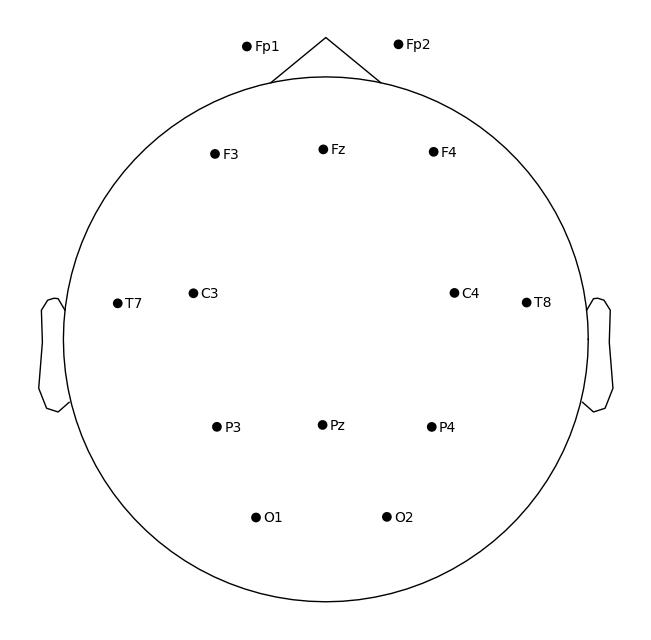

block 00 saved → ../bids_dataset/sub-lina/ses-02/eeg/sub-lina_ses-02_task-musicphrases-sing_run-01_eeg.fif
   → metadata saved: sub-lina_ses-02_task-musicphrases-sing_run-01_eeg.json
EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
block 01 saved → ../bids_dataset/sub-lina/ses-02/eeg/sub-lina_ses-02_task-musicphrases-sing_run-02_eeg.fif
   → metadata saved: sub-lina_ses-02_task-musicphrases-sing_run-02_eeg.json
EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
block 02 saved → ../bids_dataset/sub-lina/ses-02/eeg/sub-lina_ses-02_task-musicphrases-sing_run-03_eeg.fif
   → metadata saved: sub-lina_ses-02_task-musicphrases-sing_run-03_eeg.json

In [16]:
# DataFrame → RawArray → .fif + .json
out_dir = CONFIG['raw_dir']
out_dir.mkdir(exist_ok=True)

eeg_cols   = CONFIG['ch_order']
marker_col = "D12"

mne_names  = [ch.replace("T3", "T7").replace("T4", "T8") for ch in eeg_cols] + ["stim"]
ch_types   = ["eeg"] * 14 + ["stim"]

for k, df in enumerate(blocks):
    # --- 1. select EEG counts & marker -----------------------------------
    counts = df[eeg_cols].to_numpy(dtype=float).T
    stim   = df[[marker_col]].to_numpy(dtype=float).T

    # --- 2. counts → Volts -----------------------------------------------
    data_volts = counts * (UV_PER_COUNT * 1e-6)
    data       = np.vstack([data_volts, stim])

    # --- 3. build RawArray -----------------------------------------------
    info = mne.create_info(mne_names, sfreq=SFREQ, ch_types=ch_types)
    raw  = mne.io.RawArray(data, info, verbose=False)
    raw.set_montage("standard_1020")
    raw.set_eeg_reference('average', projection=True)

    # --- 4. metadata -----------------------------------------------------
    raw.info['subject_info'] = dict(
        id=1,
        first_name='Lina',
        birthday=datetime.date(1985, 7, 1)
    )
    raw.info['line_freq']    = 50
    raw.info['experimenter'] = 'Lina Lopes'
    raw.info['description']  = 'Creativity in vitro – 21/06/2025'

    # --- 5. quick sensor plot for first block ----------------------------
    if k == 0:
        print("proj list:", raw.info['projs'])
        raw.plot_sensors(kind="topomap", show_names=True, sphere=0.09)

    # --- 6. save .fif + .json --------------------------------------------
    bids_name = f"sub-lina_ses-02_task-musicphrases-sing_run-{k+1:02d}_eeg"
    fname = out_dir / f"{bids_name}.fif"
    raw.save(fname, overwrite=True, verbose=False)
    print(f"block {k:02d} saved →", fname)

    # --- 7. save BIDS-compliant JSON metadata ----------------------------
    json_metadata = {
        "TaskName": "musicphrases",
        "InstitutionName": "Creativity in vitro",
        "SamplingFrequency": raw.info["sfreq"],
        "EEGReference": "average",
        "PowerLineFrequency": 50,
        "EEGChannelCount": 14,
        "SoftwareFilters": {
            "HighPass": 1.0,
            "LowPass": 45.0,
            "Notch": [50, 60]
        },
        "CapManufacturer": "OpenBCI"
    }

    json_path = out_dir / f"{bids_name}.json"
    with open(json_path, "w") as f:
        json.dump(json_metadata, f, indent=4)
    print("   → metadata saved:", json_path.name)


In [17]:
# Define participants table
participants = pd.DataFrame([
    {"participant_id": "sub-lina", "age": 39, "sex": "F", "handedness": "R"}
])

# Save to BIDS root folder
participants_path = Path("../bids_dataset/participants.tsv")
participants.to_csv(participants_path, sep="\t", index=False)

print("✓ participants.tsv saved to", participants_path)


✓ participants.tsv saved to ../bids_dataset/participants.tsv


In [15]:
# 3-D sensor positions – no head surface, no trans needed
mne.viz.plot_alignment(
    raw.info,
    coord_frame="head",   # default is 'head'; keeps numbers in cm
    eeg="original",       # draw EEG sensors as stored
    dig=True,             # include digitization / montage points
    show_axes=True,
    surfaces=[],          # <-- remove 'head' surface => no trans required
    verbose=False
)


## 4. Linear filtering & cropping (21 blocks)

In this step, we apply **zero-phase FIR filtering** and crop each recording block using the experimental trigger.

### Filtering:
- **Band-pass 1–45 Hz** (Hamming window, 53 dB stopband attenuation)
- **Dual notch filters at 50 and 60 Hz** (to reject powerline harmonics)
- All filters are **non-causal, zero-phase** (symmetric FIR)

### Cropping:
- We detect the **first falling edge (1 → 0)** of the `D12` button trigger (stored in the `stim` channel)
- We **discard all data prior to the trigger**
- The remaining signal — from the trigger to the end of the block — is retained

### Referencing:
- The **average-reference projector** remains stored in `info['projs']`, but is **kept OFF**
- It will be activated only prior to ICA

Each processed block is saved as a BIDS-compliant file:
sub-lina_ses-02_task-musicphrases-sing_run-##_desc-filtcrop_eeg.fif

This marks a frozen checkpoint: *clean and aligned data*, ready for ICA and further analysis.


In [19]:
# Filtering + cropping with task + baseline split (BIDS-compliant)

in_dir  = CONFIG['raw_dir']
out_dir = CONFIG['fif_dir']
out_dir.mkdir(parents=True, exist_ok=True)

raw_files = sorted(in_dir.glob("sub-lina_ses-02_task-musicphrases-sing_run-*_eeg.fif"))

for f_in in raw_files:
    run_str = f_in.name.split("_")[3]  # e.g. 'run-01'
    run_num = int(run_str.split("-")[1])
    print("processing", run_str)

    raw = mne.io.read_raw_fif(f_in, preload=True, verbose=False)

    # Apply filters
    raw.filter(0.1, 45., fir_design="firwin", phase="zero-double")
    raw.notch_filter([50, 60], fir_design="firwin", phase="zero-double")

    # Find trigger: 1 → 0 in 'stim'
    d12 = raw.copy().pick_channels(["stim"]).get_data()[0].astype(int)
    trigger_sample = None
    for i in range(1, len(d12)):
        if d12[i-1] == 1 and d12[i] == 0:
            trigger_sample = i
            break

    if trigger_sample is None:
        print(f"   ⚠️ no trigger (1→0) found in {run_str}, skipping")
        continue

    sfreq = raw.info['sfreq']
    trigger_time = trigger_sample / sfreq
    t_task_end = trigger_time + 133.0
    t_baseline_end = t_task_end + 3.0

    if t_baseline_end > raw.times[-1]:
        print(f"   ⚠️ block too short for task + baseline in {run_str}, skipping")
        continue

    # Split raw
    raw_task = raw.copy().crop(tmin=trigger_time, tmax=t_task_end)
    raw_base = raw.copy().crop(tmin=t_task_end, tmax=t_baseline_end)

    # -------- Save TASK (main block) --------
    task_name = f"sub-lina_ses-02_task-musicphrases-sing_run-{run_num:02d}_desc-filtcrop_eeg"
    f_task = out_dir / f"{task_name}.fif"
    raw_task.save(f_task, overwrite=True)
    print("   → task saved:", f_task.name)

    json_task = {
        "TaskName": "musicphrases",
        "SamplingFrequency": sfreq,
        "EEGReference": "average",
        "PowerLineFrequency": raw.info.get("line_freq", 50),
        "EEGChannelCount": len([ch for ch in raw.info["chs"] if ch['kind'] == mne.io.constants.FIFF.FIFFV_EEG_CH]),
        "SoftwareFilters": {"HighPass": 1.0, "LowPass": 45.0, "Notch": [50, 60]},
        "Description": "Filtered EEG task segment (133s) after trigger.",
        "Authors": ["Lina Lopes"]
    }

    with open(f_task.with_suffix(".json"), "w") as f:
        json.dump(json_task, f, indent=4)

    # -------- Save BASELINE (final 3s) --------
    base_name = f"sub-lina_ses-02_task-musicphrases-sing_run-{run_num:02d}_desc-baseline_eeg"
    f_base = out_dir / f"{base_name}.fif"
    raw_base.save(f_base, overwrite=True)
    print("   → baseline saved:", f_base.name)

    json_base = json_task.copy()
    json_base["Description"] = "Filtered EEG baseline segment (final 3s after task)."

    with open(f_base.with_suffix(".json"), "w") as f:
        json.dump(json_base, f, indent=4)


processing run-01
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 45 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-12 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-12 dB cutoff frequency: 50.62 Hz)
- Filter length: 4125 samples (33.000 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz

[Parallel(n_jobs=1)]: Done  14 out of  14 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  14 out of  14 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  14 out of  14 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  14 out of  14 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  14 out of  14 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  14 out of  14 | elapsed:    0.0s finished


   → baseline saved: sub-lina_ses-02_task-musicphrases-sing_run-03_desc-baseline_eeg.fif
processing run-04
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 45 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-12 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-12 dB cutoff frequency: 50.62 Hz)
- Filter length: 4125 samples (33.000 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopban

[Parallel(n_jobs=1)]: Done  14 out of  14 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  14 out of  14 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  14 out of  14 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  14 out of  14 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  14 out of  14 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  14 out of  14 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  14 out of  14 | elapsed:    0.1s finished


FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 825 samples (6.600 s)

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Writing /Users/linalopes/Desktop/creativity-in-vitro-eeg/notebooks/../bids_dataset/derivatives/filt_crop/sub-lina/ses-02/eeg/sub-lina_ses-02_task-musicphrases-sing_run-07_desc-filtcrop_eeg.fif
Closing /Users/linalopes/Desktop/creativity-in-vitro-eeg/notebooks/../bids_dataset/derivatives/filt_crop/sub-lina/ses-02/eeg/sub-lina_ses-02_task-musicphrases-sing_run-07_desc-filtcrop_eeg.fif
[done]
   → task saved: sub-lina_ses-02_task-musicphrases-sing_run-07_desc-filtcrop_eeg.fif
Writing /Users/linalopes/Desktop/creativity-in-vitro-eeg/notebooks/../bids_dat

...

Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 825 samples (6.600 s)

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Writing /Users/linalopes/Desktop/creativity-in-vitro-eeg/notebooks/../bids_dataset/derivatives/filt_crop/sub-lina/ses-02/eeg/sub-lina_ses-02_task-musicphrases-sing_run-14_desc-filtcrop_eeg.fif
Closing /Users/linalopes/Desktop/creativity-in-vitro-eeg/notebooks/../bids_dataset/derivatives/filt_crop/sub-lina/ses-02/eeg/sub-lina_ses-02_task-musicphrases-sing_run-14_desc-filtcrop_eeg.fif
[done]
   → task saved: sub-lina_ses-02_task-musicphrases-sing_run-14_desc-filtcrop_eeg.fif
Writin

[Parallel(n_jobs=1)]: Done  14 out of  14 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  14 out of  14 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  14 out of  14 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  14 out of  14 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  14 out of  14 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  14 out of  14 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  14 out of  14 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  14 out of  14 | elapsed:    0.0s finished


Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 825 samples (6.600 s)

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Writing /Users/linalopes/Desktop/creativity-in-vitro-eeg/notebooks/../bids_dataset/derivatives/filt_crop/sub-lina/ses-02/eeg/sub-lina_ses-02_task-musicphrases-sing_run-18_desc-filtcrop_eeg.fif
Closing /Users/linalopes/Desktop/creativity-in-vitro-eeg/notebooks/../bids_dataset/derivatives/filt_crop/sub-lina/ses-02/eeg/sub-lina_ses-02_task-musicphrases-sing_run-18_desc-filtcrop_eeg.fif
[done]
   → task saved: sub-lina_ses-02_task-musicphrases-sing_run-18_desc-filtcrop_eeg.fif
Writin

[Parallel(n_jobs=1)]: Done  14 out of  14 | elapsed:    0.1s finished
[Parallel(n_jobs=1)]: Done  14 out of  14 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  14 out of  14 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  14 out of  14 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  14 out of  14 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  14 out of  14 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  14 out of  14 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  14 out of  14 | elapsed:    0.0s finished


Closing /Users/linalopes/Desktop/creativity-in-vitro-eeg/notebooks/../bids_dataset/derivatives/filt_crop/sub-lina/ses-02/eeg/sub-lina_ses-02_task-musicphrases-sing_run-21_desc-baseline_eeg.fif
[done]
   → baseline saved: sub-lina_ses-02_task-musicphrases-sing_run-21_desc-baseline_eeg.fif


In [20]:
filt_crop_dir = CONFIG['fif_dir']
min_duration = 133  # seconds

fif_files = sorted(filt_crop_dir.glob("*desc-filtcrop_eeg.fif"))

print(f"Checking {len(fif_files)} files:\n")

for fpath in fif_files:
    raw = mne.io.read_raw_fif(fpath, preload=False, verbose=False)
    duration_sec = raw.n_times / raw.info['sfreq']

    status = "✓ OK" if duration_sec >= min_duration else "⚠️ SHORT"
    print(f"{fpath.name:<70} → {duration_sec:6.2f} s  {status}")


Checking 21 files:

sub-lina_ses-02_task-musicphrases-sing_run-01_desc-filtcrop_eeg.fif    → 133.01 s  ✓ OK
sub-lina_ses-02_task-musicphrases-sing_run-02_desc-filtcrop_eeg.fif    → 133.01 s  ✓ OK
sub-lina_ses-02_task-musicphrases-sing_run-03_desc-filtcrop_eeg.fif    → 133.01 s  ✓ OK
sub-lina_ses-02_task-musicphrases-sing_run-04_desc-filtcrop_eeg.fif    → 133.01 s  ✓ OK
sub-lina_ses-02_task-musicphrases-sing_run-05_desc-filtcrop_eeg.fif    → 133.01 s  ✓ OK
sub-lina_ses-02_task-musicphrases-sing_run-06_desc-filtcrop_eeg.fif    → 133.01 s  ✓ OK
sub-lina_ses-02_task-musicphrases-sing_run-07_desc-filtcrop_eeg.fif    → 133.01 s  ✓ OK
sub-lina_ses-02_task-musicphrases-sing_run-08_desc-filtcrop_eeg.fif    → 133.01 s  ✓ OK
sub-lina_ses-02_task-musicphrases-sing_run-09_desc-filtcrop_eeg.fif    → 133.01 s  ✓ OK
sub-lina_ses-02_task-musicphrases-sing_run-10_desc-filtcrop_eeg.fif    → 133.01 s  ✓ OK
sub-lina_ses-02_task-musicphrases-sing_run-11_desc-filtcrop_eeg.fif    → 133.01 s  ✓ OK
sub-lina_ses

## 5. SNR, signal check

### 5a · Quick SNR check (power ratio)

We approximate SNR as **mean power 1–40 Hz / mean power 55–62 Hz**.

In [21]:
def quick_snr(raw, sig=(1, 45), noi=(40, 62), db=False):
    """
    Median-channel SNR for a Raw object.
    `sig`  = signal band (Hz)
    `noi`  = noise band  (Hz) — will be clipped to Nyquist if needed.
    """
    nyq = raw.info['sfreq'] / 2.0
    noi_high = min(noi[1], nyq - 0.1)        # stay below Nyquist

    psd = raw.compute_psd(
        fmin=sig[0], fmax=noi_high,
        n_fft=int(raw.info['sfreq'] * 2),
        verbose=False
    )
    f = psd.freqs
    p = psd.get_data(picks='eeg')

    sig_pow = p[:, (sig[0] <= f) & (f <= sig[1])].mean(axis=1)
    noi_pow = p[:, (noi[0] <= f) & (f <= noi_high)].mean(axis=1)

    snr = np.median(sig_pow / noi_pow)
    return 10 * np.log10(snr) if db else snr


In [23]:
# Quick SNR check for a given run using new BIDS-compliant filenames

idx = 18  # ← run index (1-based)
run_str = f"run-{idx+1:02d}"

pre_file = CONFIG['raw_dir'] / f"sub-lina_ses-02_task-musicphrases-sing_{run_str}_eeg.fif"
post_file = CONFIG['fif_dir'] / f"sub-lina_ses-02_task-musicphrases-sing_{run_str}_desc-filtcrop_eeg.fif"

raw_pre  = mne.io.read_raw_fif(pre_file,  preload=True, verbose=False)
raw_post = mne.io.read_raw_fif(post_file, preload=True, verbose=False)

print(f"▶︎ File: {run_str}")
print(f"SNR before: {quick_snr(raw_pre,  db=True):.2f} dB")
print(f"SNR after : {quick_snr(raw_post, db=True):.2f} dB")


▶︎ File: run-19
SNR before: -6.12 dB
SNR after : 9.67 dB


### 5b · SNR table for all 21 blocks

We loop through every `blk##_raw.fif` and its corresponding  
`blk##_flt-crop_raw.fif`, compute the **log-SNR (dB)** with  
`quick_snr(db=True)`, and print a compact table:

| block | SNR before | SNR after | Δ (dB) |
|-------|-----------|-----------|--------|
| …     | …         | …         | …      |

A Δ > +10 dB usually indicates the filters worked; any block with a
smaller gain may need a closer look.


In [24]:
# SNR table for all 21 BIDS-compliant blocks
rows = []

for k in range(21):
    run_str = f"run-{k+1:02d}"

    pre_file  = CONFIG['raw_dir'] / f"sub-lina_ses-02_task-musicphrases-sing_{run_str}_eeg.fif"
    post_file = CONFIG['fif_dir'] / f"sub-lina_ses-02_task-musicphrases-sing_{run_str}_desc-filtcrop_eeg.fif"

    raw_pre  = mne.io.read_raw_fif(pre_file,  preload=True, verbose=False)
    raw_post = mne.io.read_raw_fif(post_file, preload=True, verbose=False)

    s_before = quick_snr(raw_pre,  db=True)
    s_after  = quick_snr(raw_post, db=True)

    rows.append((run_str, s_before, s_after, s_after - s_before))

print(f"{'run':<8}{'before(dB)':>12}{'after(dB)':>12}{'Δ(dB)':>9}")
for run, b, a, d in rows:
    print(f"{run:<8}{b:12.2f}{a:12.2f}{d:9.2f}")


run       before(dB)   after(dB)    Δ(dB)
run-01         -1.60        9.39    10.98
run-02         -1.84        8.92    10.76
run-03         -2.77        8.94    11.71
run-04         -2.53        9.04    11.57
run-05         -2.15        9.41    11.56
run-06         -1.55        9.10    10.65
run-07         -1.91        9.11    11.02
run-08         -2.72        9.53    12.25
run-09         -3.41        9.52    12.93
run-10         -2.30        9.54    11.84
run-11         -1.14       10.14    11.28
run-12         -1.96        9.06    11.02
run-13         -2.34        9.87    12.20
run-14         -2.17        9.73    11.89
run-15         -2.28        9.26    11.54
run-16         -2.03        8.95    10.98
run-17         -2.25        9.11    11.35
run-18         -2.71        9.49    12.20
run-19         -6.12        9.67    15.79
run-20         -2.48        9.65    12.13
run-21         -2.31        8.82    11.14


### 5c · Fancy QA (Quality Assurance) — PSD, butterfly & variance topomap  

This cell builds an interactive **MNE‐Report** for any chosen block:

* **PSD overlay (dB)** – red = before, green = after  
* **10-s butterfly traces** (200 µV/div) before **and** after  
* **Channel variance topomap** (before vs after)

Change `idx` to inspect a different block; an HTML file
`qa_block##.html` is saved next to the notebook.


##### Power spectral density (PSD) overlay — before vs after filtering & cropping

This figure shows the **frequency-domain profile** of one EEG block, comparing the signal **before** and **after** linear filtering and cropping.

* **Red = raw EEG** — includes full recording block, including noise at edges and powerline interference.  
* **Green = filtered EEG** — cropped to the 133 s task segment after D12 trigger, with high-pass and dual-notch filters applied.  
* The PSD is averaged over channels; dB scale allows quick comparison.

Reading the plot:

| Frequency band | What to observe        | Why it matters                        |
|----------------|------------------------|---------------------------------------|
| < 1 Hz         | Strong red, flat green | Drift removed by 1 Hz high-pass       |
| 50–60 Hz       | Sharp red peaks        | Notch filters suppress powerline noise |
| 1–45 Hz        | Similar shape          | Core neural bands preserved (α, β)    |
| > 45 Hz        | Green roll-off         | Confirms low-pass cutoff at 45 Hz     |

This overlay confirms that:
- The filters **preserve the meaningful content**
- The **post-trigger crop** avoids contamination from initial artefacts
- And the SNR increases without spectral distortion.

Use tooltips in the interactive figure to inspect per-channel PSDs.

Effective window size : 16.384 (s)


Effective window size : 16.384 (s)
Plotting power spectral density (dB=True).
Plotting power spectral density (dB=True).


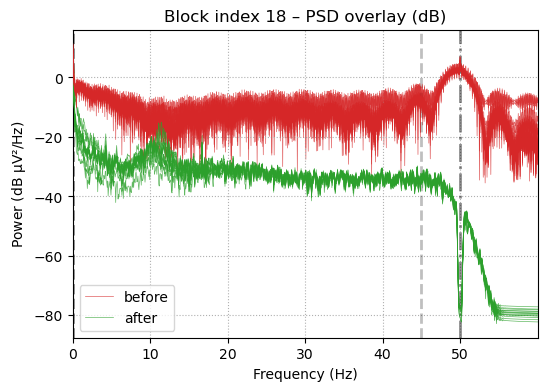

In [25]:
# PSD overlay (before vs. after) for one block
idx = 18  # block index to inspect

pre_file  = CONFIG['raw_dir'] / f"sub-lina_ses-02_task-musicphrases-sing_run-{idx+1:02d}_eeg.fif"
post_file = CONFIG['fif_dir'] / f"sub-lina_ses-02_task-musicphrases-sing_run-{idx+1:02d}_desc-filtcrop_eeg.fif"

raw_pre  = mne.io.read_raw_fif(pre_file,  preload=True, verbose=False)
raw_post = mne.io.read_raw_fif(post_file, preload=True, verbose=False)

psd_pre  = raw_pre.compute_psd(fmax=60, picks="eeg")
psd_post = raw_post.compute_psd(fmax=60, picks="eeg")

fig, ax = plt.subplots(figsize=(6, 4))

# --- plot BEFORE ---
psd_pre.plot(axes=ax, color="tab:red",  spatial_colors=False,
             dB=True, show=False)
ax.lines[-1].set_label("before")  # label the thick aggregate line

# --- plot AFTER ---
psd_post.plot(axes=ax, color="tab:green", spatial_colors=False,
              dB=True, show=False)
ax.lines[-1].set_label("after")

ax.legend()
ax.set_title(f"Block index {idx:02d} – PSD overlay (dB)")
plt.show()


##### Butterfly traces (10 s) — before vs after filtering

This 10-second **butterfly view** overlays all EEG channels to show the effect of linear filtering.

Key points we check here:

* **DC offset and low-frequency drift** have been removed.  
* **No channel is saturated, flat-lined, or artefact-heavy.**  
* High-frequency activity is preserved but cleaner.

Both plots use the **same vertical scale (2 µV/div)** to allow direct visual comparison.  
This view complements the PSD overlay and helps detect residual artefacts that may not show up in the frequency domain.


In [26]:
# Butterfly traces (before vs. after)
idx = 18  # block index to inspect

pre_file  = CONFIG['raw_dir'] / f"sub-lina_ses-02_task-musicphrases-sing_run-{idx+1:02d}_eeg.fif"
post_file = CONFIG['fif_dir'] / f"sub-lina_ses-02_task-musicphrases-sing_run-{idx+1:02d}_desc-filtcrop_eeg.fif"

raw_pre  = mne.io.read_raw_fif(pre_file,  preload=True, verbose=False)
raw_post = mne.io.read_raw_fif(post_file, preload=True, verbose=False)

# --- BEFORE filtering ----------------------------------------------------
raw_pre.plot(
    duration=10, start=0, butterfly=True,
    picks="eeg",
    remove_dc=True,                 # subtract mean per channel for display
    scalings=dict(eeg=2e-6),
    title=f"Block {idx:02d} – BEFORE filtering (2 µV/div)"
)

# --- AFTER filtering -----------------------------------------------------
raw_post.plot(
    duration=10, start=0, butterfly=True,
    picks="eeg",
    remove_dc=True,                 # keep baselines centred
    scalings=dict(eeg=2e-6),        # 10 µV/div is common convention
    title=f"Block {idx:02d} – AFTER filtering (2 µV/div)"
)


Using qt as 2D backend.
Using pyopengl with version 3.1.9
Using pyopengl with version 3.1.9


Channels marked as bad:
none
Channels marked as bad:
none


##### Channel-wise browser (10 s) — before vs after filtering

This 10-second **channel-by-channel view** displays all 14 EEG channels using their standard 10–20 positions (Fp1 … P4), each on its own horizontal track.

Unlike the butterfly plot, this layout helps you spot **spatially localized issues**, such as:

* Persistent **DC offsets** or baseline shifts specific to a channel  
* **Flat-lines** (bad electrode contact) or **saturation/clipping** artefacts  
* **Polarity errors** (e.g., inverted traces)  
* High-frequency artefacts affecting only one region  

Both plots are shown with **automatic vertical scaling** (`scalings="auto"`), so each version adapts to its own signal dynamics.  
Use this view to **visually confirm filtering effects** and verify that no channel was lost or distorted in the process.

Scroll and zoom to explore the full trace across time and space.


In [27]:
# trace before vs. after (consistent variable names)
idx = 18  # block you want to inspect

pre_file  = CONFIG['raw_dir'] / f"sub-lina_ses-02_task-musicphrases-sing_run-{idx+1:02d}_eeg.fif"
post_file = CONFIG['fif_dir'] / f"sub-lina_ses-02_task-musicphrases-sing_run-{idx+1:02d}_desc-filtcrop_eeg.fif"

raw_pre  = mne.io.read_raw_fif(pre_file,  preload=True, verbose=False)
raw_post = mne.io.read_raw_fif(post_file, preload=True, verbose=False)

print("\n=== Traces before filtering (10 s) ===")
raw_pre.plot(
    duration=10, n_channels=len(raw_pre.ch_names),
    scalings="auto"
)

print("\n=== Traces after filtering (10 s) ===")
raw_post.plot(
    duration=10, n_channels=len(raw_post.ch_names),
    scalings="auto"
)



=== Traces before filtering (10 s) ===
Using pyopengl with version 3.1.9

=== Traces after filtering (10 s) ===
Using pyopengl with version 3.1.9


Channels marked as bad:
none
Channels marked as bad:
none


##### Variance topomap — before vs after filtering

The **channel-wise variance** (σ² in µV²) provides a quick spatial overview of signal stability across the scalp.

This visual diagnostic helps detect electrodes that are consistently noisier than the rest — for example:

* **High variance before filtering** may indicate DC drift, mains interference, or poor electrode contact.  
* **After filtering and cropping**, the topomap should become more homogeneous;  
  any electrode that still stands out may need to be rejected or interpolated before ICA.

In this plot:

- We compute the **empirical covariance** matrix for each stage.  
- We extract the **diagonal** to get per-channel variance.  
- Both topomaps use the **same color scale** for direct comparison.

This is especially useful when deciding whether to apply average reference or run ICA.


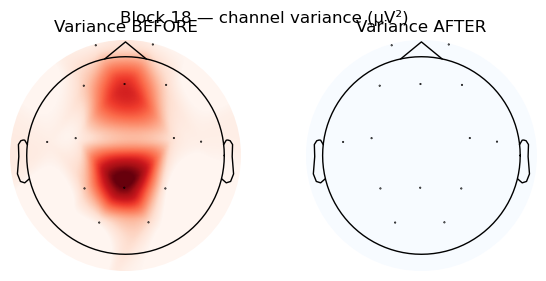

In [28]:
# Variance topomap before vs. after filtering (consistent variable names)
idx = 18  # block you want to inspect

pre_file  = CONFIG['raw_dir'] / f"sub-lina_ses-02_task-musicphrases-sing_run-{idx+1:02d}_eeg.fif"
post_file = CONFIG['fif_dir'] / f"sub-lina_ses-02_task-musicphrases-sing_run-{idx+1:02d}_desc-filtcrop_eeg.fif"

raw_pre  = mne.io.read_raw_fif(pre_file,  preload=True, verbose=False)
raw_post = mne.io.read_raw_fif(post_file, preload=True, verbose=False)

# keep only EEG; remove DC for fair comparison
raw_pre_eeg  = (raw_pre.copy()
                .pick("eeg")
                .apply_function(lambda x: x - x.mean(-1, keepdims=True)))
raw_post_eeg = (raw_post.copy()
                .pick("eeg")
                .apply_function(lambda x: x - x.mean(-1, keepdims=True)))

# empirical covariance → diagonal elements are variances (µV²)
cov_pre  = mne.compute_raw_covariance(raw_pre_eeg,  method="empirical", verbose=False)
cov_post = mne.compute_raw_covariance(raw_post_eeg, method="empirical", verbose=False)
var_pre  = cov_pre.data.diagonal()
var_post = cov_post.data.diagonal()

# common color scale
vlim = (min(var_pre.min(), var_post.min()),
        max(var_pre.max(), var_post.max()))

fig, axes = plt.subplots(1, 2, figsize=(7, 3))

mne.viz.plot_topomap(
    var_pre, raw_pre.info, axes=axes[0],
    cmap="Reds", vlim=vlim, contours=0, sphere=0.09, show=False
)
axes[0].set_title("Variance BEFORE")

mne.viz.plot_topomap(
    var_post, raw_post.info, axes=axes[1],
    cmap="Blues", vlim=vlim, contours=0, sphere=0.09, show=False
)
axes[1].set_title("Variance AFTER")

fig.suptitle(f"Block {idx:02d} — channel variance (µV²)")
plt.show()


### 5d · Check that blinks / artefacts do not saturate  

After correcting the count → Volt scaling, we expect typical peak EEG
amplitudes of **±5–20 µV** in resting state and up to **±100 µV** for eye
blinks.  Anything beyond ±200 µV would indicate possible saturation or a bad
electrode.

* **Visual:** butterfly at **20 µV / div** to make small peaks visible.  
* **Automatic:** peak-finder per block prints the maximum absolute µV; a
  value \< 200 µV is considered OK.


In [29]:
# Automatic peak amplitude scan (all 21 BIDS-formatted blocks)

def peak_uV(raw):
    """Return max absolute amplitude (µV) per channel."""
    data = raw.get_data(picks="eeg") * 1e6  # V → µV
    return np.max(np.abs(data), axis=1)

thr = 100  # µV threshold for flagging large peaks
fif_dir = CONFIG['fif_dir']

print(f"{'run':<8}{'max_peak(µV)':>12}{'status':>9}")
for k in range(21):
    run_str = f"run-{k+1:02d}"
    fpath = fif_dir / f"sub-lina_ses-02_task-musicphrases-sing_{run_str}_desc-filtcrop_eeg.fif"

    if not fpath.exists():
        print(f"{run_str:<8}{'missing':>12}")
        continue

    raw = mne.io.read_raw_fif(fpath, preload=True, verbose=False)
    peak = peak_uV(raw).max()
    flag = "OK" if peak <= thr else "⚠️  high"
    print(f"{run_str:<8}{peak:12.1f}{flag:>9}")


run     max_peak(µV)   status
run-01           3.7       OK
run-02           3.4       OK
run-03           2.8       OK
run-04           7.5       OK
run-05           3.7       OK
run-06           2.8       OK
run-07           6.3       OK
run-08           3.0       OK
run-09           6.3       OK
run-10           3.8       OK
run-11           7.3       OK
run-12           8.0       OK
run-13           2.8       OK
run-14           3.3       OK
run-15           4.1       OK
run-16           3.1       OK
run-17           3.7       OK
run-18           3.3       OK
run-19           3.1       OK
run-20           6.0       OK
run-21           2.4       OK


## 6. Master report

Click a block in the expandable list to view its full set of QA figures
(PSD, butterfly, variance map).  The HTML is saved alongside the
cleaned `.fif` files for easy sharing.


In [30]:
def butterfly_static(raw, title,
                     scale_uV,            # µV per division
                     n_div=5, dur=10,
                     remove_dc=True):
    """Static butterfly plot with fixed scale."""
    sf = raw.info['sfreq']
    t_stop = int(dur * sf)
    data, times = raw.get_data(picks="eeg", stop=t_stop, return_times=True)
    data *= 1e6                                # V → µV
    if remove_dc:
        data -= data.mean(-1, keepdims=True)

    lim = scale_uV * n_div
    fig, ax = plt.subplots(figsize=(6, 2.5))
    for ch in data:
        ax.plot(times, ch, lw=.4, color="k")

    ax.set_ylim(-lim, lim)
    ax.set_xlabel("Time (s)"); ax.set_ylabel("µV")
    ax.set_title(f"{title}  ({scale_uV} µV/div)")
    ax.grid(ls=":", alpha=.3)
    return fig


In [31]:
# Build HTML QA report for one block (BIDS-compliant version, QA in correct folder)

def make_block_report(idx,
                      raw_dir=CONFIG['raw_dir'],
                      fif_dir=CONFIG['fif_dir'],
                      qa_dir=CONFIG['qa_dir']):  # ← usa CONFIG['qa_dir'] como default
    """
    Create qa_run-##.html and return the MNE Report object.

    Parameters
    ----------
    idx : int
        Block index (0-based). Will be mapped to run-01, run-02, etc.
    raw_dir : Path or str
        Directory with original raw .fif files (e.g., no filters).
    fif_dir : Path or str
        Directory with filtered + cropped .fif files.
    qa_dir : Path or str
        Directory to save the HTML QA report. Defaults to CONFIG['qa_dir'].
    """
    qa_dir = Path(qa_dir)
    qa_dir.mkdir(parents=True, exist_ok=True)

    run_str = f"run-{idx+1:02d}"

    # Load raw data
    raw_pre = mne.io.read_raw_fif(
        Path(raw_dir) / f"sub-lina_ses-02_task-musicphrases-sing_{run_str}_eeg.fif",
        preload=True, verbose=False
    )
    raw_post = mne.io.read_raw_fif(
        Path(fif_dir) / f"sub-lina_ses-02_task-musicphrases-sing_{run_str}_desc-filtcrop_eeg.fif",
        preload=True, verbose=False
    )

    # PSD overlay
    fig_psd, ax = plt.subplots(figsize=(6, 3))
    for raw, col, lab in [
        (raw_pre,  "tab:red",   "before"),
        (raw_post, "tab:green", "after")
    ]:
        raw.compute_psd(fmax=60, picks="eeg").plot(
            axes=ax, color=col, spatial_colors=False, dB=True, show=False
        )
        ax.lines[-1].set_label(lab)
    ax.legend(); ax.set_title("PSD overlay (dB)")
    plt.close(fig_psd)

    # Butterfly plots
    fig_bt_pre = butterfly_static(raw_pre,  "Butterfly BEFORE", scale_uV=20, remove_dc=False)
    fig_bt_post = butterfly_static(raw_post, "Butterfly AFTER", scale_uV=2, remove_dc=True)
    plt.close(fig_bt_pre); plt.close(fig_bt_post)

    # Channel variance maps
    def var_diag(r):
        r = (r.copy()
               .pick("eeg")
               .apply_function(lambda x: x - x.mean(-1, keepdims=True)))
        cov = mne.compute_raw_covariance(r, method="empirical", verbose=False)
        return cov.data.diagonal()

    var_pre, var_post = var_diag(raw_pre), var_diag(raw_post)
    vlim = (min(var_pre.min(), var_post.min()), max(var_pre.max(), var_post.max()))

    fig_var, axes = plt.subplots(1, 2, figsize=(6, 3))
    mne.viz.plot_topomap(var_pre, raw_pre.info, axes=axes[0],
                         cmap="Reds", vlim=vlim, contours=0,
                         sphere=0.09, show=False)
    axes[0].set_title("Variance BEFORE")

    mne.viz.plot_topomap(var_post, raw_post.info, axes=axes[1],
                         cmap="Blues", vlim=vlim, contours=0,
                         sphere=0.09, show=False)
    axes[1].set_title("Variance AFTER")
    fig_var.suptitle("Channel variance (µV²)")
    plt.close(fig_var)

    # Build and save report
    rep = mne.Report(title=f"QA {run_str}")
    rep.add_figure(fig_psd,     title="PSD overlay")
    rep.add_figure(fig_bt_pre,  title="Butterfly BEFORE")
    rep.add_figure(fig_bt_post, title="Butterfly AFTER")
    rep.add_figure(fig_var,     title="Channel variance")

    out_html = qa_dir / f"qa_{run_str}.html"
    rep.save(out_html, overwrite=True, open_browser=False, verbose=False)
    print(f"✔ saved {out_html}")

    return rep


In [32]:
# Generate reports for ALL 21 blocks -------------------------------
for k in range(21):
    make_block_report(k)


Effective window size : 16.384 (s)
Plotting power spectral density (dB=True).
Effective window size : 16.384 (s)
Plotting power spectral density (dB=True).
Embedding : jquery-3.6.0.min.js
Embedding : bootstrap.bundle.min.js
Embedding : bootstrap.min.css
Embedding : bootstrap-table/bootstrap-table.min.js
Embedding : bootstrap-table/bootstrap-table.min.css
Embedding : bootstrap-table/bootstrap-table-copy-rows.min.js
Embedding : bootstrap-table/bootstrap-table-export.min.js
Embedding : bootstrap-table/tableExport.min.js
Embedding : bootstrap-icons/bootstrap-icons.mne.min.css
Embedding : highlightjs/highlight.min.js
Embedding : highlightjs/atom-one-dark-reasonable.min.css
✔ saved ../bids_dataset/derivatives/qa_reports/sub-lina/ses-02/eeg/qa_run-01.html
Effective window size : 16.384 (s)
Plotting power spectral density (dB=True).
Effective window size : 16.384 (s)
Plotting power spectral density (dB=True).
Embedding : jquery-3.6.0.min.js
Embedding : bootstrap.bundle.min.js
Embedding : boots

In [33]:
# Build master QA report (merging all 21 run reports)

qa_dir = CONFIG['qa_dir']
master = mne.Report(title="Creativity in Vitro — QA (21 runs)")

for k in range(21):
    run_str = f"run-{k+1:02d}"
    p = qa_dir / f"qa_{run_str}.html"

    if p.exists():
        html = p.read_text(encoding="utf-8")
        wrapper = (
            f"<details><summary style='font-size:120%;'>Run {k+1:02d}</summary>"
            f"{html}</details>"
        )
        master.add_html(wrapper, title=f"{run_str}")
    else:
        print(f"⚠️ missing: {p.name}")

out_master = qa_dir / "QA_all_runs.html"
master.save(out_master, overwrite=True, open_browser=False)
print(f"🌐 Master report → {out_master}")


Embedding : jquery-3.6.0.min.js
Embedding : bootstrap.bundle.min.js
Embedding : bootstrap.min.css
Embedding : bootstrap-table/bootstrap-table.min.js
Embedding : bootstrap-table/bootstrap-table.min.css
Embedding : bootstrap-table/bootstrap-table-copy-rows.min.js
Embedding : bootstrap-table/bootstrap-table-export.min.js
Embedding : bootstrap-table/tableExport.min.js
Embedding : bootstrap-icons/bootstrap-icons.mne.min.css
Embedding : highlightjs/highlight.min.js
Embedding : highlightjs/atom-one-dark-reasonable.min.css
Overwriting existing file.
Saving report to : /Users/linalopes/Desktop/creativity-in-vitro-eeg/bids_dataset/derivatives/qa_reports/sub-lina/ses-02/eeg/QA_all_runs.html
🌐 Master report → ../bids_dataset/derivatives/qa_reports/sub-lina/ses-02/eeg/QA_all_runs.html
